In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE
import time
import SoftImpute
import TabCSDI


In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from SoftImpute import softimpute, cv_softimpute
from TabCSDI import TabCSDIImputer


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time


In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [11]:
import pandas as pd

# Direct UCI URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

# The dataset has no header row, so specify header=None and separator=';'
data = pd.read_csv(url, sep=';', header=None)

print("Shape:", data.shape)
print(data.head())


Shape: (1055, 42)
      0       1   2   3   4   5   6     7   8   9   ...  32  33  34     35  \
0  3.919  2.6909   0   0   0   0   0  31.4   2   0  ...   0   0   0  2.949   
1  4.170  2.1144   0   0   0   0   0  30.8   1   1  ...   0   0   0  3.315   
2  3.932  3.2512   0   0   0   0   0  26.7   2   4  ...   0   0   1  3.076   
3  3.000  2.7098   0   0   0   0   0  20.0   0   2  ...   0   0   1  3.046   
4  4.236  3.3944   0   0   0   0   0  29.4   2   4  ...   0   0   0  3.351   

      36  37     38  39  40  41  
0  1.591   0  7.253   0   0  RB  
1  1.967   0  7.257   0   0  RB  
2  2.417   0  7.601   0   0  RB  
3  5.000   0  6.690   0   0  RB  
4  2.405   0  8.003   0   0  RB  

[5 rows x 42 columns]


In [13]:
fixed_columns = [
 'SpMax_L', 'J_Dz(e)', 'nHM', 'F01[N-N]', 'F04[C-N]', 'NssssC', 'nCb-',
 'C%', 'nCp', 'nCconj', 'nC', 'nN', 'nArNO2', 'nCRX3', 'SpPosA_B(p)',
 'nCRX2', 'B01[C-Br]', 'B03[C-Cl]', 'N-073', 'SpMax_A', 'Psi_i_1d',
 'B04[C-Br]', 'B05[C-Br]', 'nRCONH2', 'nRCNR', 'nOHp', 'nCOOH', 'nArOH',
 'nHDon', 'SpMax_B', 'Psi_i_A', 'B04[C-Cl]', 'B05[C-Cl]', 'SM6_L', 'CIC0',
 'SM1_Dz(Z)', 'nArCOOR', 'nArNHR', 'nArNR2', 'nNHR', 'nNR2', 'Class'
]

print("Length of new list:", len(fixed_columns))


data.columns = fixed_columns
print(data.head())


Length of new list: 42
   SpMax_L  J_Dz(e)  nHM  F01[N-N]  F04[C-N]  NssssC  nCb-    C%  nCp  nCconj  \
0    3.919   2.6909    0         0         0       0     0  31.4    2       0   
1    4.170   2.1144    0         0         0       0     0  30.8    1       1   
2    3.932   3.2512    0         0         0       0     0  26.7    2       4   
3    3.000   2.7098    0         0         0       0     0  20.0    0       2   
4    4.236   3.3944    0         0         0       0     0  29.4    2       4   

   ...  B05[C-Cl]  SM6_L  CIC0  SM1_Dz(Z)  nArCOOR  nArNHR  nArNR2  nNHR  \
0  ...          0      0     0      2.949    1.591       0   7.253     0   
1  ...          0      0     0      3.315    1.967       0   7.257     0   
2  ...          0      0     1      3.076    2.417       0   7.601     0   
3  ...          0      0     1      3.046    5.000       0   6.690     0   
4  ...          0      0     0      3.351    2.405       0   8.003     0   

   nNR2  Class  
0     0     RB  

In [14]:
print("Shape:", data.shape)
print(data.head())

Shape: (1055, 42)
   SpMax_L  J_Dz(e)  nHM  F01[N-N]  F04[C-N]  NssssC  nCb-    C%  nCp  nCconj  \
0    3.919   2.6909    0         0         0       0     0  31.4    2       0   
1    4.170   2.1144    0         0         0       0     0  30.8    1       1   
2    3.932   3.2512    0         0         0       0     0  26.7    2       4   
3    3.000   2.7098    0         0         0       0     0  20.0    0       2   
4    4.236   3.3944    0         0         0       0     0  29.4    2       4   

   ...  B05[C-Cl]  SM6_L  CIC0  SM1_Dz(Z)  nArCOOR  nArNHR  nArNR2  nNHR  \
0  ...          0      0     0      2.949    1.591       0   7.253     0   
1  ...          0      0     0      3.315    1.967       0   7.257     0   
2  ...          0      0     1      3.076    2.417       0   7.601     0   
3  ...          0      0     1      3.046    5.000       0   6.690     0   
4  ...          0      0     0      3.351    2.405       0   8.003     0   

   nNR2  Class  
0     0     RB  
1   

In [17]:
X_full = data.drop(columns=['Class'])

y = data['Class']

In [18]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 41 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SpMax_L      1055 non-null   float64
 1   J_Dz(e)      1055 non-null   float64
 2   nHM          1055 non-null   int64  
 3   F01[N-N]     1055 non-null   int64  
 4   F04[C-N]     1055 non-null   int64  
 5   NssssC       1055 non-null   int64  
 6   nCb-         1055 non-null   int64  
 7   C%           1055 non-null   float64
 8   nCp          1055 non-null   int64  
 9   nCconj       1055 non-null   int64  
 10  nC           1055 non-null   int64  
 11  nN           1055 non-null   float64
 12  nArNO2       1055 non-null   float64
 13  nCRX3        1055 non-null   float64
 14  SpPosA_B(p)  1055 non-null   float64
 15  nCRX2        1055 non-null   int64  
 16  B01[C-Br]    1055 non-null   float64
 17  B03[C-Cl]    1055 non-null   float64
 18  N-073        1055 non-null   int64  
 19  SpMax_

In [19]:
scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

In [20]:
GroundTruth = X_full.copy()
X = X_full.copy()

print(GroundTruth)

       SpMax_L   J_Dz(e)       nHM  F01[N-N]   F04[C-N]    NssssC      nCb-  \
0    -1.579865 -0.455652 -0.490223 -0.166690  -0.420308 -0.270248 -0.740386   
1    -1.120710 -1.149466 -0.490223 -0.166690  -0.420308 -0.270248 -0.740386   
2    -1.556084  0.218665 -0.490223 -0.166690  -0.420308 -0.270248 -0.740386   
3    -3.260993 -0.432906 -0.490223 -0.166690  -0.420308 -0.270248 -0.740386   
4    -0.999976  0.391006 -0.490223 -0.166690  -0.420308 -0.270248 -0.740386   
...        ...       ...       ...       ...        ...       ...       ...   
1050  1.186039 -0.209417 -0.490223 -0.166690  -0.420308  1.593229 -0.740386   
1051  0.922620  0.365492 -0.490223 -0.166690   3.439291 -0.270248 -0.740386   
1052  0.157972 -1.567560 -0.490223  3.741254   3.439291 -0.270248  1.508051   
1053  0.686640 -1.658544  0.877992 -0.166690  15.018086 -0.270248  3.306800   
1054  0.536637 -0.494284  0.877992 -0.166690  -0.420308 -0.270248  1.058364   

            C%       nCp    nCconj  ...  B04[C-Cl] 

In [22]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)
GroundTruth.nunique()

SpMax_L         440
J_Dz(e)        1022
nHM              11
F01[N-N]          4
F04[C-N]         16
NssssC           13
nCb-             15
C%              188
nCp              15
nCconj           12
nC               21
nN              384
nArNO2          756
nCRX3           373
SpPosA_B(p)     510
nCRX2            24
B01[C-Br]       167
B03[C-Cl]       125
N-073             3
SpMax_A           4
Psi_i_1d          4
B04[C-Br]       352
B05[C-Br]        13
nRCONH2           2
nRCNR             2
nOHp              4
nCOOH           329
nArOH           205
nHDon             2
SpMax_B         470
Psi_i_A         553
B04[C-Cl]         8
B05[C-Cl]        11
SM6_L            16
CIC0              8
SM1_Dz(Z)       705
nArCOOR         624
nArNHR            8
nArNR2          862
nNHR              5
nNR2             17
dtype: int64

In [23]:
# assumes GroundTruth is your fully observed, scaled dataframe (no missing values yet)
mean_SpMax_L                 = GroundTruth["SpMax_L"].mean()
median_J_Dz_e                = GroundTruth["J_Dz(e)"].median()
mean_nHM                     = GroundTruth["nHM"].mean()
median_F01_N_N               = GroundTruth["F01[N-N]"].median()
mean_F04_C_N                 = GroundTruth["F04[C-N]"].mean()
median_NssssC                = GroundTruth["NssssC"].median()
mean_nCb                     = GroundTruth["nCb-"].mean()
median_Cperc                 = GroundTruth["C%"].median()
mean_nCp                     = GroundTruth["nCp"].mean()
median_nCconj                = GroundTruth["nCconj"].median()
mean_nC                      = GroundTruth["nC"].mean()
median_nN                    = GroundTruth["nN"].median()
mean_nArNO2                  = GroundTruth["nArNO2"].mean()
median_nCRX3                 = GroundTruth["nCRX3"].median()
mean_SpPosA_B_p              = GroundTruth["SpPosA_B(p)"].mean()
median_nCRX2                 = GroundTruth["nCRX2"].median()
mean_B01_C_Br                = GroundTruth["B01[C-Br]"].mean()
median_B03_C_Cl              = GroundTruth["B03[C-Cl]"].median()
mean_N_073                   = GroundTruth["N-073"].mean()
median_SpMax_A               = GroundTruth["SpMax_A"].median()
mean_Psi_i_1d                = GroundTruth["Psi_i_1d"].mean()
median_B04_C_Br              = GroundTruth["B04[C-Br]"].median()
mean_B05_C_Br                = GroundTruth["B05[C-Br]"].mean()
median_nRCONH2               = GroundTruth["nRCONH2"].median()
mean_nRCNR                   = GroundTruth["nRCNR"].mean()
median_nOHp                  = GroundTruth["nOHp"].median()
mean_nCOOH                   = GroundTruth["nCOOH"].mean()
median_nArOH                 = GroundTruth["nArOH"].median()
mean_nHDon                   = GroundTruth["nHDon"].mean()
median_SpMax_B               = GroundTruth["SpMax_B"].median()
mean_Psi_i_A                 = GroundTruth["Psi_i_A"].mean()
median_B04_C_Cl              = GroundTruth["B04[C-Cl]"].median()
mean_B05_C_Cl                = GroundTruth["B05[C-Cl]"].mean()
median_SM6_L                 = GroundTruth["SM6_L"].median()
mean_CIC0                    = GroundTruth["CIC0"].mean()
median_SM1_Dz_Z              = GroundTruth["SM1_Dz(Z)"].median()
mean_nArCOOR                 = GroundTruth["nArCOOR"].mean()
median_nArNHR                = GroundTruth["nArNHR"].median()
mean_nArNR2                  = GroundTruth["nArNR2"].mean()
median_nNHR                  = GroundTruth["nNHR"].median()
mean_nNR2                    = GroundTruth["nNR2"].mean()
dependencies_mar = {
    "SpMax_L": {
        "influencers": ["J_Dz(e)"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["J_Dz(e)"] > median_J_Dz_e else 0.1
    },
    "J_Dz(e)": {
        "influencers": ["nHM"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nHM"] > mean_nHM else 0.1
    },
    "nHM": {
        "influencers": ["F01[N-N]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["F01[N-N]"] > median_F01_N_N else 0.1
    },
    "F01[N-N]": {
        "influencers": ["F04[C-N]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["F04[C-N]"] > mean_F04_C_N else 0.1
    },
    "F04[C-N]": {
        "influencers": ["NssssC"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["NssssC"] > median_NssssC else 0.1
    },
    "NssssC": {
        "influencers": ["nCb-"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nCb-"] > mean_nCb else 0.1
    },
    "nCb-": {
        "influencers": ["C%"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["C%"] > median_Cperc else 0.1
    },
    "C%": {
        "influencers": ["nCp"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nCp"] > mean_nCp else 0.1
    },
    "nCp": {
        "influencers": ["nCconj"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nCconj"] > median_nCconj else 0.1
    },
    "nCconj": {
        "influencers": ["nC"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nC"] > mean_nC else 0.1
    },
    "nC": {
        "influencers": ["nN"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nN"] > median_nN else 0.1
    },
    "nN": {
        "influencers": ["nArNO2"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nArNO2"] > mean_nArNO2 else 0.1
    },
    "nArNO2": {
        "influencers": ["nCRX3"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nCRX3"] > median_nCRX3 else 0.1
    },
    "nCRX3": {
        "influencers": ["SpPosA_B(p)"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["SpPosA_B(p)"] > mean_SpPosA_B_p else 0.1
    },
    "SpPosA_B(p)": {
        "influencers": ["nCRX2"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nCRX2"] > median_nCRX2 else 0.1
    },
    "nCRX2": {
        "influencers": ["B01[C-Br]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["B01[C-Br]"] > mean_B01_C_Br else 0.1
    },
    "B01[C-Br]": {
        "influencers": ["B03[C-Cl]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["B03[C-Cl]"] > median_B03_C_Cl else 0.1
    },
    "B03[C-Cl]": {
        "influencers": ["N-073"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["N-073"] > mean_N_073 else 0.1
    },
    "N-073": {
        "influencers": ["SpMax_A"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["SpMax_A"] > median_SpMax_A else 0.1
    },
    "SpMax_A": {
        "influencers": ["Psi_i_1d"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Psi_i_1d"] > mean_Psi_i_1d else 0.1
    },
    "Psi_i_1d": {
        "influencers": ["B04[C-Br]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["B04[C-Br]"] > median_B04_C_Br else 0.1
    },
    "B04[C-Br]": {
        "influencers": ["B05[C-Br]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["B05[C-Br]"] > mean_B05_C_Br else 0.1
    },
    "B05[C-Br]": {
        "influencers": ["nRCONH2"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nRCONH2"] > median_nRCONH2 else 0.1
    },
    "nRCONH2": {
        "influencers": ["nRCNR"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nRCNR"] > mean_nRCNR else 0.1
    },
    "nRCNR": {
        "influencers": ["nOHp"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nOHp"] > median_nOHp else 0.1
    },
    "nOHp": {
        "influencers": ["nCOOH"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nCOOH"] > mean_nCOOH else 0.1
    },
    "nCOOH": {
        "influencers": ["nArOH"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nArOH"] > median_nArOH else 0.1
    },
    "nArOH": {
        "influencers": ["nHDon"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nHDon"] > mean_nHDon else 0.1
    },
    "nHDon": {
        "influencers": ["SpMax_B"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["SpMax_B"] > median_SpMax_B else 0.1
    },
    "SpMax_B": {
        "influencers": ["Psi_i_A"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["Psi_i_A"] > mean_Psi_i_A else 0.1
    },
    "Psi_i_A": {
        "influencers": ["B04[C-Cl]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["B04[C-Cl]"] > median_B04_C_Cl else 0.1
    },
    "B04[C-Cl]": {
        "influencers": ["B05[C-Cl]"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["B05[C-Cl]"] > mean_B05_C_Cl else 0.1
    },
    "B05[C-Cl]": {
        "influencers": ["SM6_L"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["SM6_L"] > median_SM6_L else 0.1
    },
    "SM6_L": {
        "influencers": ["CIC0"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["CIC0"] > mean_CIC0 else 0.1
    },
    "CIC0": {
        "influencers": ["SM1_Dz(Z)"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["SM1_Dz(Z)"] > median_SM1_Dz_Z else 0.1
    },
    "SM1_Dz(Z)": {
        "influencers": ["nArCOOR"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nArCOOR"] > mean_nArCOOR else 0.1
    },
    "nArCOOR": {
        "influencers": ["nArNHR"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nArNHR"] > median_nArNHR else 0.1
    },
    "nArNHR": {
        "influencers": ["nArNR2"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nArNR2"] > mean_nArNR2 else 0.1
    },
    "nArNR2": {
        "influencers": ["nNHR"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nNHR"] > median_nNHR else 0.1
    },
    "nNHR": {
        "influencers": ["nNR2"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nNR2"] > mean_nNR2 else 0.1
    },
    "nNR2": {
        "influencers": ["SpMax_L"],  # loop back to the first feature to close the ring
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["SpMax_L"] > mean_SpMax_L else 0.1
    }
}


In [26]:
dependencies_mnar = {
    "SpMax_L": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["SpMax_L"] > mean_SpMax_L else 0.1
    },
    "J_Dz(e)": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["J_Dz(e)"] > median_J_Dz_e else 0.1
    },
    "nHM": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nHM"] > mean_nHM else 0.1
    },
    "F01[N-N]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["F01[N-N]"] > median_F01_N_N else 0.1
    },
    "F04[C-N]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["F04[C-N]"] > mean_F04_C_N else 0.1
    },
    "NssssC": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["NssssC"] > median_NssssC else 0.1
    },
    "nCb-": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nCb-"] > mean_nCb else 0.1
    },
    "C%": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["C%"] > median_Cperc else 0.1
    },
    "nCp": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nCp"] > mean_nCp else 0.1
    },
    "nCconj": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nCconj"] > median_nCconj else 0.1
    },
    "nC": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nC"] > mean_nC else 0.1
    },
    "nN": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nN"] > median_nN else 0.1
    },
    "nArNO2": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nArNO2"] > mean_nArNO2 else 0.1
    },
    "nCRX3": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nCRX3"] > median_nCRX3 else 0.1
    },
    "SpPosA_B(p)": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["SpPosA_B(p)"] > mean_SpPosA_B_p else 0.1
    },
    "nCRX2": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nCRX2"] > median_nCRX2 else 0.1
    },
    "B01[C-Br]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["B01[C-Br]"] > mean_B01_C_Br else 0.1
    },
    "B03[C-Cl]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["B03[C-Cl]"] > median_B03_C_Cl else 0.1
    },
    "N-073": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["N-073"] > mean_N_073 else 0.1
    },
    "SpMax_A": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["SpMax_A"] > median_SpMax_A else 0.1
    },
    "Psi_i_1d": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["Psi_i_1d"] > mean_Psi_i_1d else 0.1
    },
    "B04[C-Br]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["B04[C-Br]"] > median_B04_C_Br else 0.1
    },
    "B05[C-Br]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["B05[C-Br]"] > mean_B05_C_Br else 0.1
    },
    "nRCONH2": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nRCONH2"] > median_nRCONH2 else 0.1
    },
    "nRCNR": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nRCNR"] > mean_nRCNR else 0.1
    },
    "nOHp": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nOHp"] > median_nOHp else 0.1
    },
    "nCOOH": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nCOOH"] > mean_nCOOH else 0.1
    },
    "nArOH": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nArOH"] > median_nArOH else 0.1
    },
    "nHDon": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nHDon"] > mean_nHDon else 0.1
    },
    "SpMax_B": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["SpMax_B"] > median_SpMax_B else 0.1
    },
    "Psi_i_A": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["Psi_i_A"] > mean_Psi_i_A else 0.1
    },
    "B04[C-Cl]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["B04[C-Cl]"] > median_B04_C_Cl else 0.1
    },
    "B05[C-Cl]": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["B05[C-Cl]"] > mean_B05_C_Cl else 0.1
    },
    "SM6_L": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["SM6_L"] > median_SM6_L else 0.1
    },
    "CIC0": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["CIC0"] > mean_CIC0 else 0.1
    },
    "SM1_Dz(Z)": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["SM1_Dz(Z)"] > median_SM1_Dz_Z else 0.1
    },
    "nArCOOR": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nArCOOR"] > mean_nArCOOR else 0.1
    },
    "nArNHR": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nArNHR"] > median_nArNHR else 0.1
    },
    "nArNR2": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nArNR2"] > mean_nArNR2 else 0.1
    },
    "nNHR": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nNHR"] > median_nNHR else 0.1
    },
    "nNR2": {
        "condition": lambda row: True,
        "probability": lambda row: 0.6 if row["nNR2"] > mean_nNR2 else 0.1
    }
}


## MCAR

Running all the algorithms multiple runs 5 times, sample runs 50 times

In [27]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=600, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    OT_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae  # mean over runs
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=50, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mcar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=1000,
            batch_size=256)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-S  (single-fit -> Run=1)
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
    mean_miwaes, std_miwaes = miwaes.fit_transform_std(miss_mcar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaes[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-S (single-fit -> Run=1)
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=1000,batch_size=256)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gains[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-U (single-fit -> Run=1)
    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mcar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaeu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-U (single-fit -> Run=1)
    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=1000,
            batch_size=256)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gainu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI
    print("TabCSDI")
    t_method_start = time.perf_counter()
    imputed_runs_tab = []
    for i in range(runs):
        print(f"Run {i+1}...")
        tab = TabCSDIImputer(
            epochs=300,
            nsamples=2,
            num_steps=500,
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4 # keep is_linear=False to avoid extra deps
        )
        X_imputed_tab = tab.fit_transform(miss_mcar.to_numpy())   # numpy out
        imputed_runs_tab.append(X_imputed_tab)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_tab[missing_mask.values])
        result_mae.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_tab = np.stack(imputed_runs_tab, axis=0)
    imputed_mean_tab  = np.nanmean(imputed_stack_tab, axis=0)
    imputed_std_tab   = np.nanstd(imputed_stack_tab, axis=0)
    total_time_sec    = time.perf_counter() - t_method_start

    tab_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_tab[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": tab_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_tab[missing_mask.values].flatten(),
                       imputed_std_tab[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "TabCSDI",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # TabCSDI-S (single-fit -> Run=1)
    print("TabCSDI-S")
    t_method_start = time.perf_counter()
    tabS = TabCSDIImputer(
        epochs=300,
            nsamples=2,
            num_steps=500,
            timeemb=64, featureemb=64,
            channels=64, layers=4, nheads=4  # keep is_linear=False to avoid extra deps
    )
    tabS.fit(miss_mcar)
    mean_tabS, std_tabS = tabS.transform_with_std(miss_mcar, num_samples=50)
    total_time_sec = time.perf_counter() - t_method_start

    mae_tabS = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_tabS[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "TabCSDI-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_tabS
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_tabS[missing_mask.values].flatten(),
                       std_tabS[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "TabCSDI-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U
TabCSDI
Run 1...
[   1/300] loss=1.009522
[  30/300] loss=0.375403
[  60/300] loss=0.343562
[  90/300] loss=0.342110
[ 120/300] loss=0.352715
[ 150/300] loss=0.344522
[ 180/300] loss=0.311603
[ 210/300] loss=0.286817
[ 240/300] loss=0.279623
[ 270/300] loss=0.265981
[ 300/300] loss=0.256841
Run 2...
[   1/300] loss=0.999144
[  30/300] loss=0.358759
[  60/300] loss=0.354858
[  90/300] loss=0.327832
[ 120/300] loss=0.375480
[ 150/300] loss=0.336117
[ 180/300] loss=0.319866
[ 210/300] loss=0.288232
[ 240/300] loss=0.269291
[ 270/300] loss=0.270503
[ 300/300] loss=0.271210
Run 3...
[   1/300] loss=0.998040
[  30/300] loss=0.359310
[  60/300] loss=0.342862
[  90/300] loss=0.361427
[ 120/300] loss=0.35

In [28]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=600, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    OT_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae  # mean over runs
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=50, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
        X_imputed_miwae = imputer.fit_transform(miss_mar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=1000,
            batch_size=256)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-S  (single-fit -> Run=1)
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
    mean_miwaes, std_miwaes = miwaes.fit_transform_std(miss_mar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaes[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-S (single-fit -> Run=1)
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=1000,batch_size=256)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gains[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-U (single-fit -> Run=1)
    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaeu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-U (single-fit -> Run=1)
    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=1000,
            batch_size=256)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gainu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    

results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U


In [29]:
missing_rates = [30]  # 10% to 90% missing

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mnar = []
result_mae = []

for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 5
    #missing mask
    missing_mask = miss_mnar.isna()

    #OT
    t_method_start = time.perf_counter()
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter=600, batchsize=64)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()  # numpy
        imputed_runs_OT.append(X_imputed_OT)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_OT[missing_mask.values])
        result_mae.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    OT_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "OT-Impute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": OT_mae  # mean over runs
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_OT[missing_mask.values].flatten(),
                       imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
        })

    #Mice
    t_method_start = time.perf_counter()
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=50, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        imputed_runs_mice.append(X_imputed_mice)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_mice[missing_mask.values])
        result_mae.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mice_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MICE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mice_mae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_mice[missing_mask.values].flatten(),
                       imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    #SoftImpute
    print("SoftImpute")
    t_method_start = time.perf_counter()
    imputed_runs_soft = []
    for i in range(runs):
        print(f"Run {i+1}...")
        missng_soft = (miss_mnar.copy()).to_numpy()
        cv_error, grid_lambda = cv_softimpute(missng_soft, grid_len=15)
        lbda = grid_lambda[np.argmin(cv_error)]
        soft_imp = softimpute((missng_soft), lbda)[1]
        imputed_runs_soft.append(soft_imp)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      soft_imp[missing_mask.values])
        result_mae.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_soft = np.stack(imputed_runs_soft, axis=0)
    imputed_mean_soft = np.nanmean(imputed_stack_soft, axis=0)
    imputed_std_soft = np.nanstd(imputed_stack_soft, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_soft = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_soft[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "SoftImpute",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_soft
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_soft[missing_mask.values].flatten(),
                       imputed_std_soft[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "SoftImpute",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE
    print("MIWAE")
    t_method_start = time.perf_counter()
    imputed_runs_miwae = []
    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mnar.copy()
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)
        imputed_runs_miwae.append(X_imputed_miwae)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_miwae[missing_mask.values])
        result_mae.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_miwae
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_miwae[missing_mask.values].flatten(),
                       imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN
    t_method_start = time.perf_counter()
    imputed_runs_gain = []
    print("GAIN")
    for i in range(runs):
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=1000,
            batch_size=256)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)
        # per-run MAE
        mae_run = mean_absolute_error(GroundTruth.values[missing_mask.values],
                                      X_imputed_gain[missing_mask.values])
        result_mae.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Run": i+1,
            "MAE": mae_run
        })

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    total_time_sec = time.perf_counter() - t_method_start

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN",
        "MissingRate": missing_rate,
        "Run": "mean",
        "MAE": mae_gain
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       imputed_mean_gain[missing_mask.values].flatten(),
                       imputed_std_gain[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-S  (single-fit -> Run=1)
    print("MIWAE-S")
    t_method_start = time.perf_counter()
    miwaes = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
    mean_miwaes, std_miwaes = miwaes.fit_transform_std(miss_mnar, return_std=True, inference_K=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaes = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaes[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaes
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaes[missing_mask.values].flatten(),
                       std_miwaes[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-S (single-fit -> Run=1)
    print("GAIN-S")
    t_method_start = time.perf_counter()
    imputer_gains = GAINImputer(epochs=1000,batch_size=256)
    X_imputed_gains = imputer_gains.fit_transform(X_missing_tensor)
    mean_gains, std_gains = imputer_gains.sample(num_samples=20)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gains = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gains[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-S",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gains
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gains[missing_mask.values].flatten(),
                       std_gains[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN-S",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # MIWAE-U (single-fit -> Run=1)
    print("MIWAE-U")
    t_method_start = time.perf_counter()
    miwaeu = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=8,
                               hidden_dims=[64, 64], K=20, epochs=1000)
    mean_miwaeu, std_miwaeu = miwaeu.fit_transform_std(miss_mnar, return_std=True, inference_K=1)
    total_time_sec = time.perf_counter() - t_method_start
    mae_miwaeu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_miwaeu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "MIWAE-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_miwaeu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_miwaeu[missing_mask.values].flatten(),
                       std_miwaeu[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    # GAIN-U (single-fit -> Run=1)
    print("GAIN-U")
    t_method_start = time.perf_counter()
    imputer_gainu = GAINU(epochs=1000,
            batch_size=256)
    mean_gainu, std_gainu = imputer_gainu.fit_transform_uncertainty(X_missing_tensor)
    total_time_sec = time.perf_counter() - t_method_start
    mae_gainu = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        mean_gainu[missing_mask.values]
    )
    result_mae.append({
        "Algorithm": "GAIN-U",
        "MissingRate": missing_rate,
        "Run": 1,
        "MAE": mae_gainu
    })
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                       mean_gainu[missing_mask.values].flatten(),
                       std_gainu[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "GAIN-U",
            "MissingRate": missing_rate,
            "Time": total_time_sec,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s
        })

    
results = pd.DataFrame(result_mae)
results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mnar_allMethod_mae.csv", index=False)

df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mnar_allMethod_results_with_all_missing_values.csv", index=False)


30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
SoftImpute
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
MIWAE-S
GAIN-S
MIWAE-U
GAIN-U


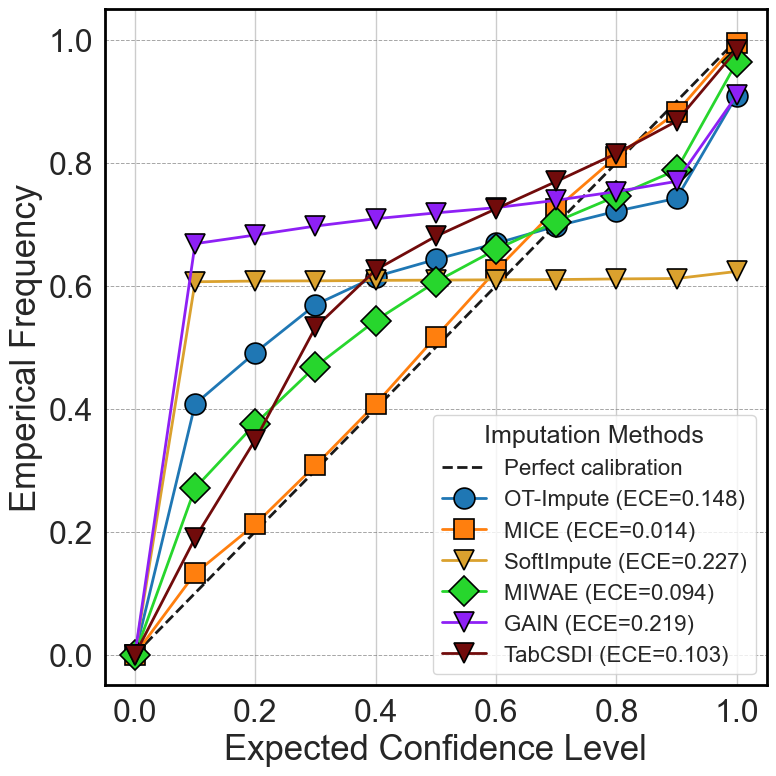

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_MCAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


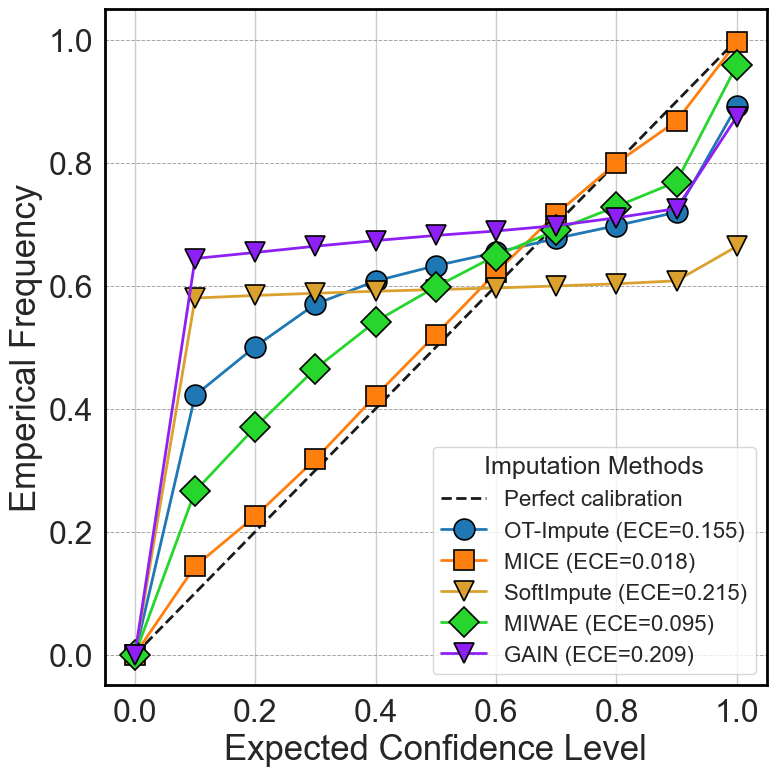

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_MAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


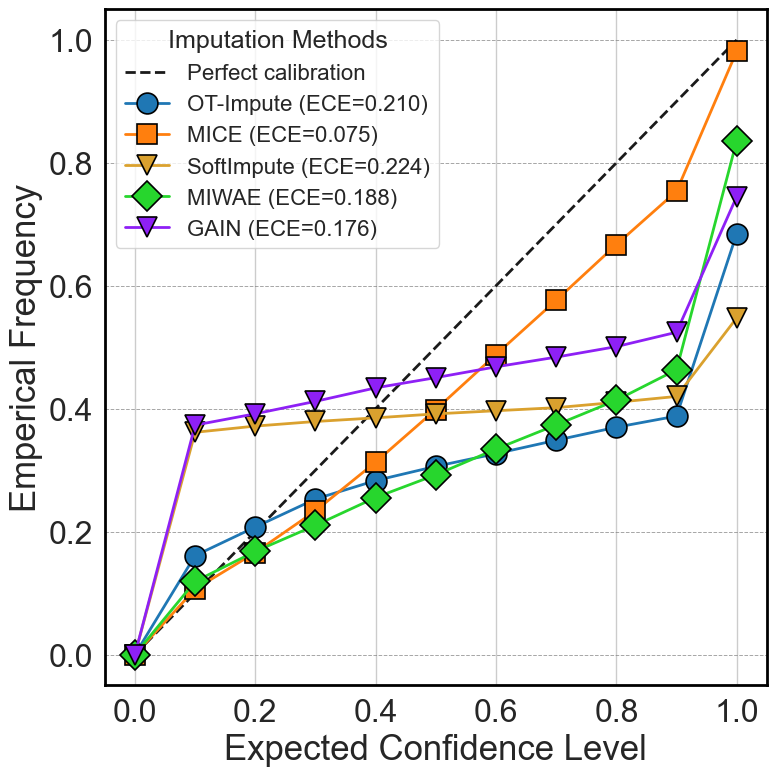

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]



algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 18
legend_label_fontsize = 16
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

   
    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},

}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    if algo == "GAIN-S" or algo == "GAIN-U" or algo == "MIWAE-U" or algo =="MIWAE-S" or algo == "TabCSDI-S":
        continue
    
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)


plt.legend(ncol=1,title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_MNAR30_CalibrationCurve_allMethods.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


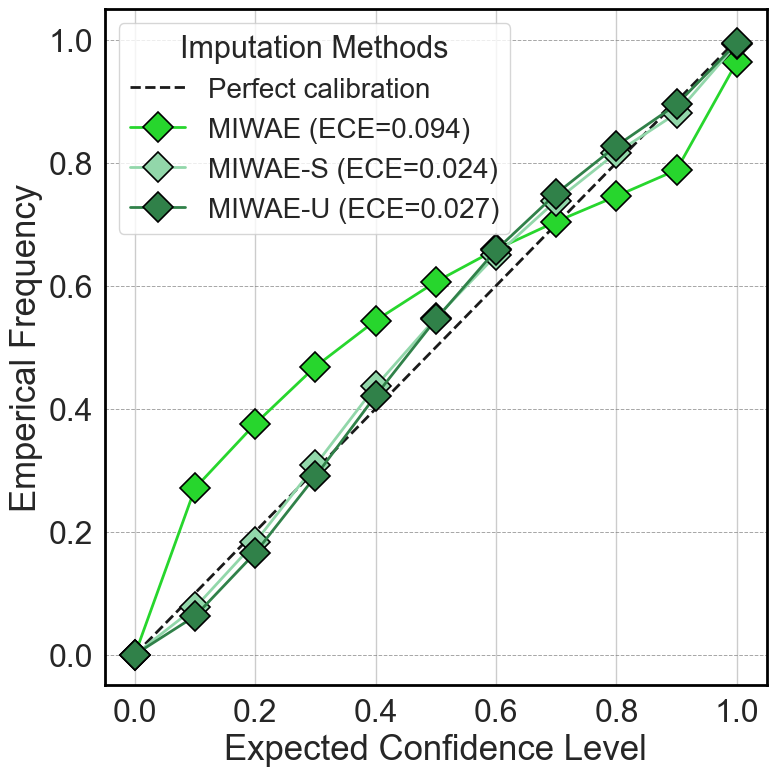

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_mcar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



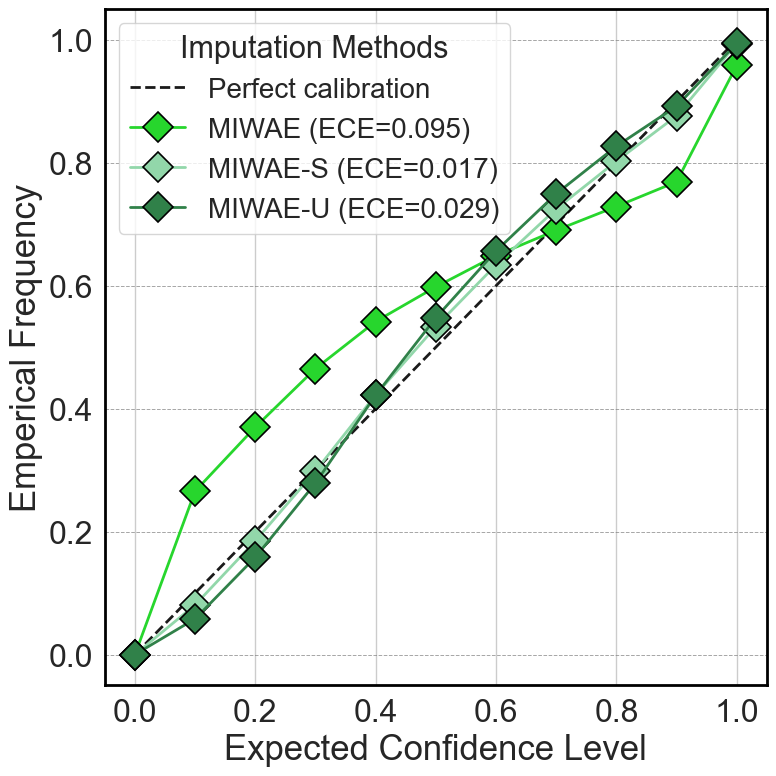

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_mar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



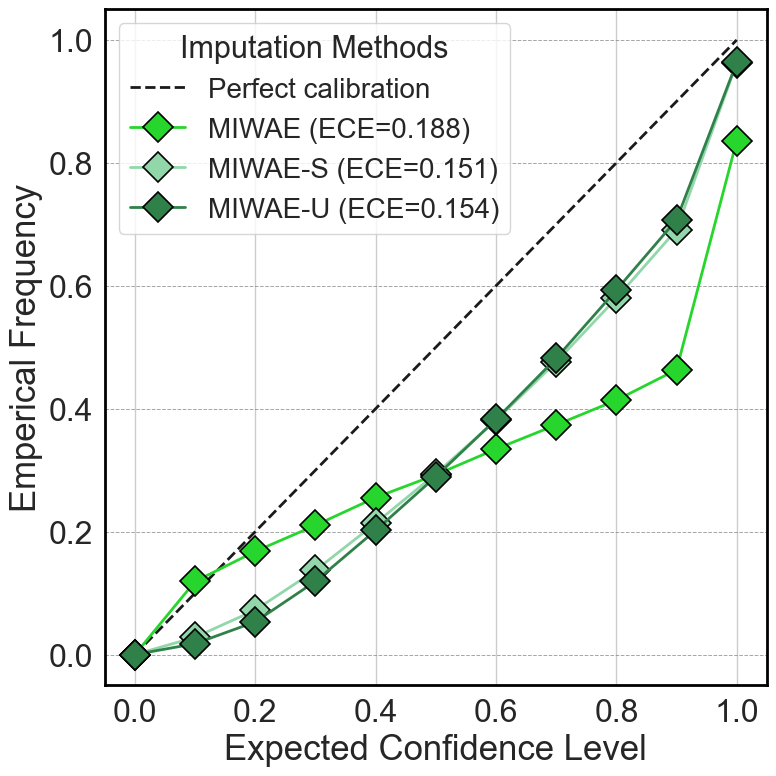

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["MIWAE", "MIWAE-S", "MIWAE-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_mnar_miwae_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



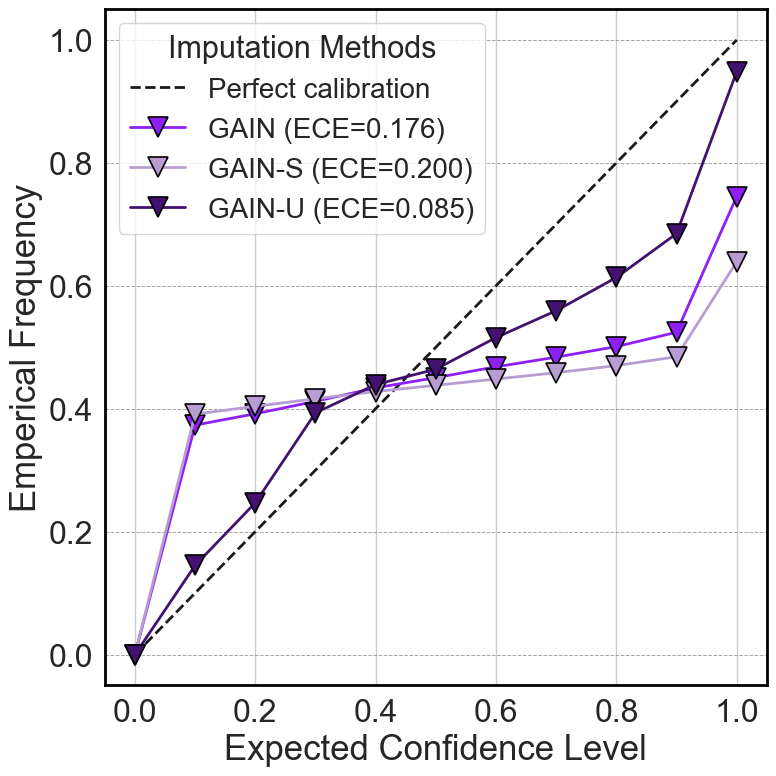

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mnar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_mnar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



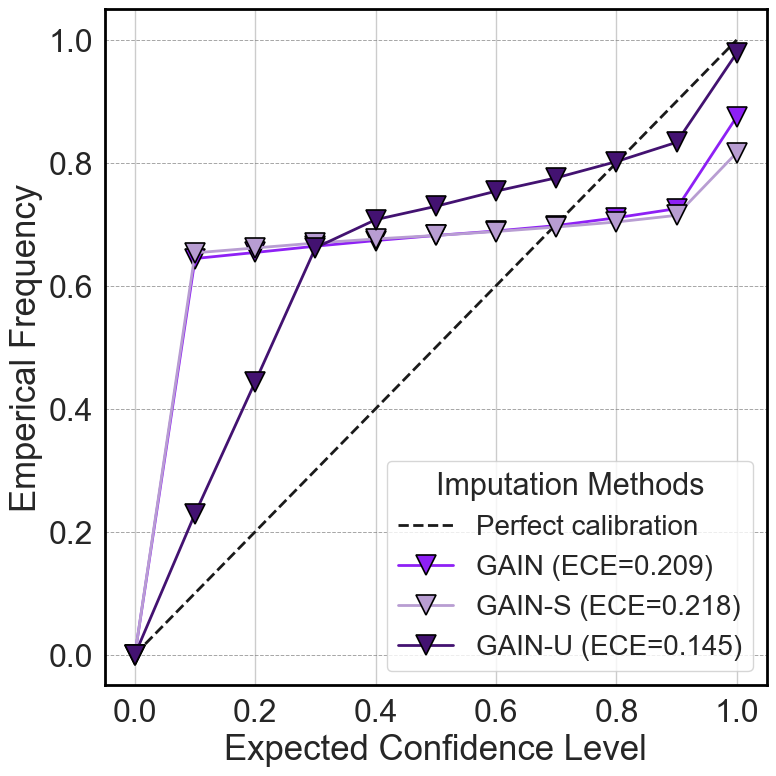

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_mar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



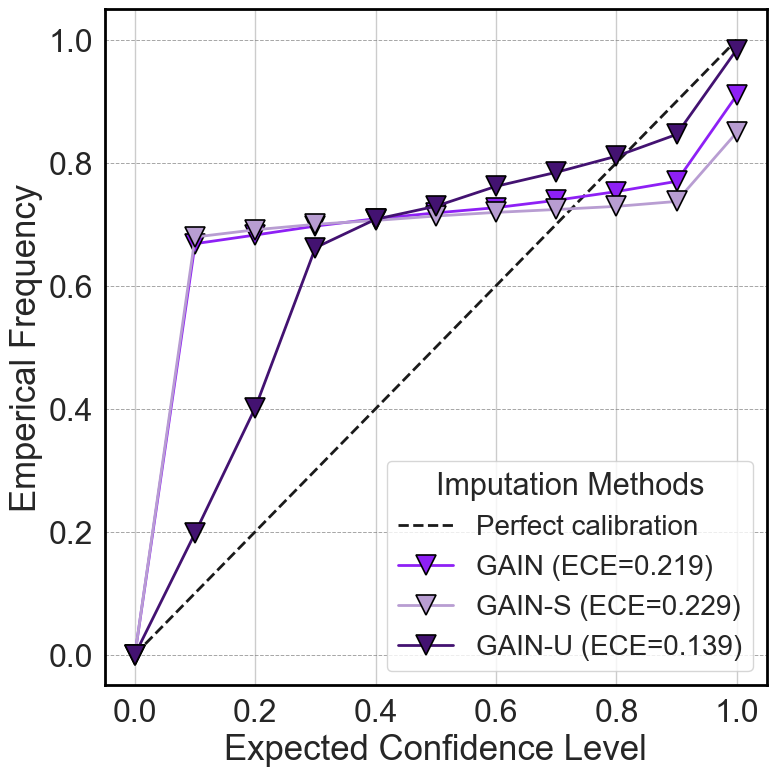

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_results_with_all_missing_values.csv"
)

target_missing_rate = 30 # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

algorithms = ["GAIN", "GAIN-S", "GAIN-U"]

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square

    "MIWAE":       {"color": "#27d62d", "marker": "D"},   # Red triangle-up
    "GAIN":        {"color": "#8e20f5", "marker": "v"},   # Purple triangle-down

    "MIWAE-S": {"color": "#92d7aa", "marker": "D"},
    "GAIN-S": {"color": "#b89dd2", "marker": "v"},
    "MIWAE-U": {"color": "#308149", "marker": "D"},
    "GAIN-U": {"color": "#431271", "marker": "v"},
    "SoftImpute": {"color": "#DAA12E", "marker": "v"},
    "TabCSDI": {"color": "#710B0B", "marker": "v"},
    "TabCSDI-S": {"color": "#CF616A", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})",
        markeredgecolor="black", markeredgewidth=1.2
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Imputation Methods",fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()


# Save PDF
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_mcar_gain_comparision_consistency.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()



C:\Users\zhossai3\AppData\Local\Temp\ipykernel_30148\2084027510.py:51: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 100000)


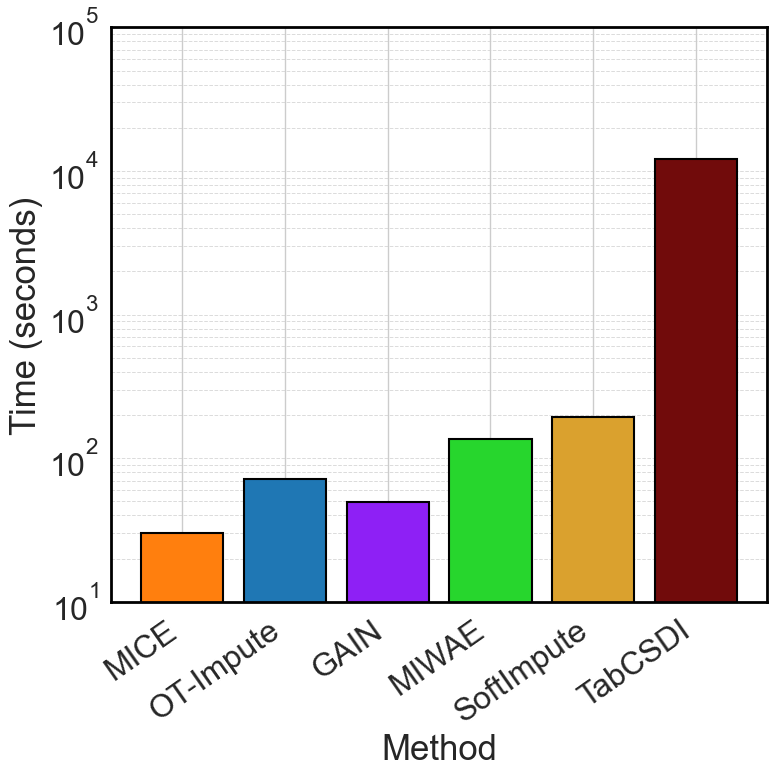

In [40]:
# Recompute and re-plot with ALL methods' times divided by 5.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_results_with_all_missing_values.csv"
df = pd.read_csv(path)

# Algorithms and colors (order preserved)
algos = ["MICE", "OT-Impute", "GAIN", "MIWAE", "SoftImpute", "TabCSDI"]
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4"},
    "MICE":        {"color": "#ff7f0e"},
    "MIWAE":       {"color": "#27d62d"},
    "GAIN":        {"color": "#8e20f5"},
    "SoftImpute":  {"color": "#DAA12E"},
    "TabCSDI":     {"color": "#710B0B"},
}

x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
})

# Divide ALL times by 5
df["TimeAdj"] = df["Time"] / 5.0

# Filter to 30% missingness and aggregate
target_mr = 30
df_30 = df[np.isclose(df["MissingRate"].astype(float), float(target_mr))].copy()
summary = (df_30.groupby("Algorithm", as_index=False)["TimeAdj"].mean())
summary = summary[summary["Algorithm"].isin(algos)]
summary["Algorithm"] = pd.Categorical(summary["Algorithm"], categories=algos, ordered=True)
summary = summary.sort_values("Algorithm")

# Plot (log y) with diagonal x-tick labels
plt.figure(figsize=(8, 8))
colors = [algo_styles[a]["color"] for a in summary["Algorithm"]]
plt.bar(summary["Algorithm"], summary["TimeAdj"], color=colors, edgecolor="black", linewidth=1.5)
plt.yscale("log")
plt.ylim(0, 100000)
plt.ylabel("Time (seconds)", fontsize=y_label_fontsize)
plt.xlabel("Method",fontsize=x_label_fontsize)
plt.xticks(rotation=35, ha='right')

# Borders and grid
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.yaxis.grid(True, which="both", linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_yticks([1e1, 1e2, 1e3, 1e4, 1e5])

plt.tight_layout()

pdf_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_time_bar_30pct_log_xticks_diag_div5all.pdf"

plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()



C:\Users\zhossai3\AppData\Local\Temp\ipykernel_30148\2666301687.py:66: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 100000)


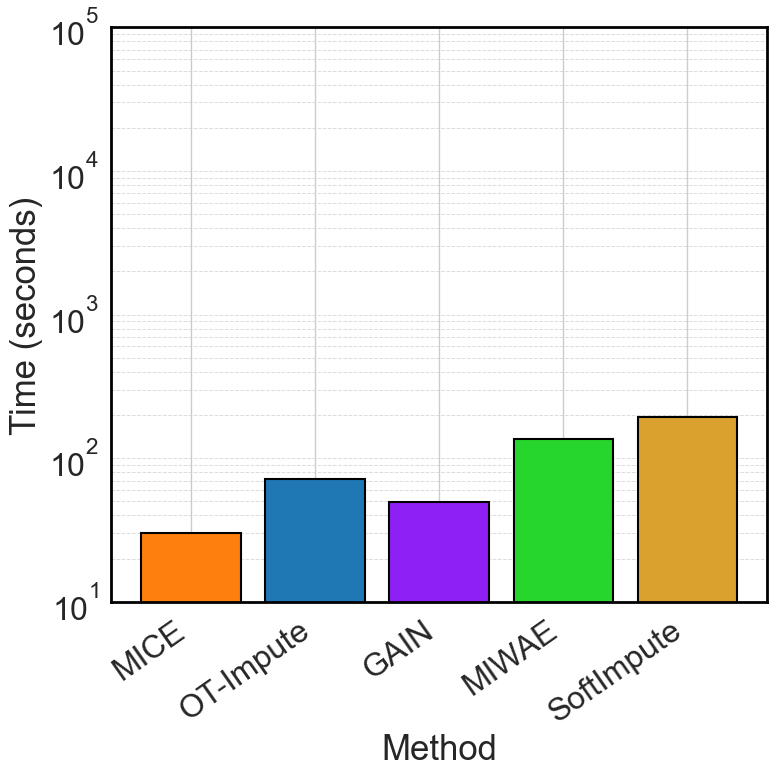

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Bio_mcar_allMethod_results_with_all_missing_values.csv"
df = pd.read_csv(path)

# Algorithms and colors (order preserved, TabCSDI removed)
algos = ["MICE", "OT-Impute", "GAIN", "MIWAE", "SoftImpute"]
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4"},
    "MICE":        {"color": "#ff7f0e"},
    "MIWAE":       {"color": "#27d62d"},
    "GAIN":        {"color": "#8e20f5"},
    "SoftImpute":  {"color": "#DAA12E"},
}

x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 22
legend_label_fontsize = 20
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
})

# Divide ALL times by 5
df["TimeAdj"] = df["Time"] / 5.0

# Filter to 30% missingness and aggregate
target_mr = 30
df_30 = df[np.isclose(df["MissingRate"].astype(float), float(target_mr))].copy()

summary = (
    df_30
    .groupby("Algorithm", as_index=False)["TimeAdj"]
    .mean()
)

# Keep only the selected algorithms (no TabCSDI)
summary = summary[summary["Algorithm"].isin(algos)]

# Keep the order consistent
summary["Algorithm"] = pd.Categorical(summary["Algorithm"], categories=algos, ordered=True)
summary = summary.sort_values("Algorithm")

# Plot (log y) with diagonal x-tick labels
plt.figure(figsize=(8, 8))
colors = [algo_styles[a]["color"] for a in summary["Algorithm"]]

plt.bar(
    summary["Algorithm"],
    summary["TimeAdj"],
    color=colors,
    edgecolor="black",
    linewidth=1.5
)

plt.yscale("log")
plt.ylim(0, 100000)

plt.ylabel("Time (seconds)", fontsize=y_label_fontsize)
plt.xlabel("Method", fontsize=x_label_fontsize)
plt.xticks(rotation=35, ha='right')

# Borders and grid
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

ax.yaxis.grid(True, which="both", linestyle='--', linewidth=0.7, alpha=0.7)

ax.set_yticks([1e1, 1e2, 1e3, 1e4, 1e5])

plt.tight_layout()

pdf_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Bio_time_bar_30pct_log_xticks_diag_div5all_noTabCSDI.pdf"
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()
